<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter3_Unsupervised_Learning_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 - Unsupervised Learning and Preprocessing

Notebook ini merangkum dan mereproduksi materi **Chapter 3** dari buku  
**Introduction to Machine Learning with Python** oleh **Andreas C. Müller & Sarah Guido**.

## Topik utama Chapter 3
1. Preprocessing dan feature scaling
2. Dimensionality reduction dengan PCA
3. Visualisasi data berdimensi tinggi dengan t-SNE
4. Clustering:
   - k-Means
   - Agglomerative Clustering
   - DBSCAN

Notebook ini berisi:
- **ringkasan teori**
- **reproduksi kode**
- **visualisasi hasil**
- **penjelasan interpretasi output**

## Identitas Mahasiswa

- **Nama:** Naufal Alif Abyan  
- **NIM:** 101032300032  
- **Mata Kuliah:** Machine Learning  
- **Tugas:** Reproduksi dan Ringkasan Chapter 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, ward

plt.style.use("default")
sns.set_style("whitegrid")

print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Konsep Dasar Unsupervised Learning

Pada **supervised learning**, model belajar dari data yang memiliki label target.  
Sebaliknya, pada **unsupervised learning**, model hanya diberi data input **tanpa label**.

Tujuan unsupervised learning antara lain:
- menemukan pola tersembunyi pada data,
- mengelompokkan data yang mirip,
- mereduksi dimensi data,
- memvisualisasikan data berdimensi tinggi.

Dalam chapter ini, ada dua fokus besar:

### A. Preprocessing
Preprocessing bertujuan membuat data lebih cocok untuk model machine learning.  
Contoh preprocessing:
- **scaling** fitur agar berada pada rentang yang sebanding,
- normalisasi,
- transformasi fitur.

### B. Unsupervised Learning
Beberapa teknik utama:
1. **PCA** → mengurangi jumlah fitur sambil mempertahankan informasi penting.
2. **t-SNE** → memvisualisasikan data berdimensi tinggi ke 2D.
3. **Clustering** → mengelompokkan data berdasarkan kemiripan.

# SECTION A — PREPROCESSING AND SCALING

## 2. Mengapa Feature Scaling Penting?

Banyak algoritma machine learning sensitif terhadap skala fitur.

Misalnya:
- jika satu fitur berada pada skala 0–1
- sementara fitur lain berada pada skala 0–100000

maka fitur dengan angka lebih besar dapat mendominasi proses pembelajaran model.

### Teknik scaling yang umum:
1. **MinMaxScaler**
   - mengubah data ke rentang 0 sampai 1
2. **StandardScaler**
   - membuat data memiliki mean 0 dan standar deviasi 1
3. **RobustScaler**
   - lebih tahan terhadap outlier karena menggunakan median dan IQR

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X_train: (426, 30)
Shape X_test : (143, 30)


In [3]:
cancer_df = pd.DataFrame(X_train, columns=cancer.feature_names)
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.094290,0.2128,0.07152,...,17.52,42.79,128.70,915.0,0.1417,0.79170,1.17000,0.23560,0.4089,0.14090
1,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.048190,0.1879,0.05852,...,16.25,26.19,109.10,809.8,0.1313,0.30300,0.18040,0.14890,0.2962,0.08472
2,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.052590,0.1586,0.05922,...,19.07,30.88,123.40,1138.0,0.1464,0.18710,0.29140,0.16090,0.3029,0.08216
3,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
4,11.85,17.46,75.54,432.7,0.08372,0.05642,0.02688,0.022800,0.1875,0.05715,...,13.06,25.75,84.35,517.8,0.1369,0.17580,0.13160,0.09140,0.3101,0.07007


## 3. Data sebelum scaling

Mari lihat ringkasan statistik data sebelum scaling.
Perhatikan bahwa tiap fitur memiliki skala yang berbeda-beda.

In [4]:
cancer_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,426.0,14.119505,3.603518,6.98100,11.632500,13.280000,15.832500,28.11000
mean texture,426.0,19.332042,4.354634,9.71000,16.187500,18.810000,21.817500,39.28000
mean perimeter,426.0,91.925399,24.841210,43.79000,74.667500,86.110000,104.025000,188.50000
mean area,426.0,656.126056,361.589181,143.50000,412.625000,544.050000,787.050000,2501.00000
mean smoothness,426.0,0.096463,0.013814,0.05263,0.086720,0.096425,0.105375,0.16340
mean compactness,426.0,0.104576,0.050997,0.01938,0.065815,0.096790,0.130475,0.28670
mean concavity,426.0,0.088522,0.079614,0.00000,0.028615,0.061400,0.132050,0.42680
mean concave points,426.0,0.048831,0.039111,0.00000,0.019787,0.033700,0.074030,0.20120
mean symmetry,426.0,0.180741,0.027155,0.10600,0.162000,0.179400,0.194575,0.30400
mean fractal dimension,426.0,0.062813,0.006788,0.05024,0.058112,0.061740,0.066075,0.09575


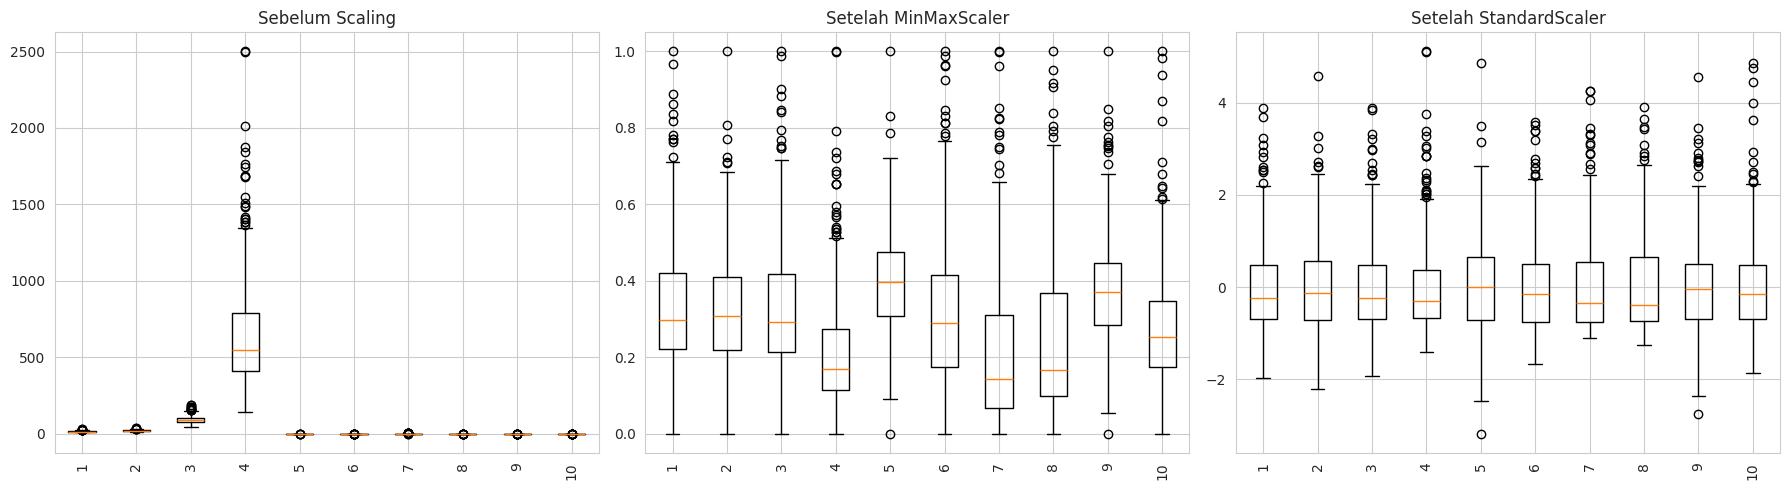

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot(X_train[:, :10])
axes[0].set_title("Sebelum Scaling")
axes[0].tick_params(axis='x', rotation=90)

minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)
axes[1].boxplot(X_train_minmax[:, :10])
axes[1].set_title("Setelah MinMaxScaler")
axes[1].tick_params(axis='x', rotation=90)

standard = StandardScaler()
X_train_standard = standard.fit_transform(X_train)
axes[2].boxplot(X_train_standard[:, :10])
axes[2].set_title("Setelah StandardScaler")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 4. MinMaxScaler

**MinMaxScaler** mentransformasi setiap fitur ke rentang **0 sampai 1**.

Rumus sederhananya:

\[
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

Kelebihan:
- skala fitur menjadi seragam
- cocok jika ingin menjaga bentuk distribusi asli

Kekurangan:
- sensitif terhadap outlier

In [6]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Min per feature (train scaled):")
print(X_train_scaled.min(axis=0)[:5])

print("\nMax per feature (train scaled):")
print(X_train_scaled.max(axis=0)[:5])

Min per feature (train scaled):
[0. 0. 0. 0. 0.]

Max per feature (train scaled):
[1. 1. 1. 1. 1.]


In [7]:
print("Data sebelum scaling (5 baris pertama, 5 kolom):")
print(pd.DataFrame(X_train[:5, :5], columns=cancer.feature_names[:5]))

print("\nData setelah MinMax scaling:")
print(pd.DataFrame(X_train_scaled[:5, :5], columns=cancer.feature_names[:5]))

Data sebelum scaling (5 baris pertama, 5 kolom):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        15.22         30.62          103.40      716.9          0.10480
1        14.96         19.10           97.03      687.3          0.08992
2        14.68         20.13           94.74      684.5          0.09867
3        10.32         16.35           65.31      324.9          0.09434
4        11.85         17.46           75.54      432.7          0.08372

Data setelah MinMax scaling:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0     0.389938      0.707136        0.411927   0.243224         0.470976
1     0.377633      0.317552        0.367908   0.230668         0.336643
2     0.364381      0.352384        0.352083   0.229480         0.415636
3     0.158029      0.224552        0.148711   0.076946         0.376546
4     0.230442      0.262090        0.219404   0.122672         0.280672


## 5. StandardScaler

**StandardScaler** mentransformasi data agar:
- mean ≈ 0
- standard deviation ≈ 1

Rumus:

\[
x' = \frac{x - \mu}{\sigma}
\]

Scaler ini sangat umum dipakai karena banyak model (misalnya SVM, logistic regression, neural network, PCA) bekerja lebih baik jika fitur berada pada skala yang sebanding.

In [8]:
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

print("Rata-rata 5 fitur pertama setelah StandardScaler:")
print(np.round(X_train_standard.mean(axis=0)[:5], 4))

print("\nStd 5 fitur pertama setelah StandardScaler:")
print(np.round(X_train_standard.std(axis=0)[:5], 4))

Rata-rata 5 fitur pertama setelah StandardScaler:
[-0.  0.  0. -0. -0.]

Std 5 fitur pertama setelah StandardScaler:
[1. 1. 1. 1. 1.]


## 6. RobustScaler

**RobustScaler** menggunakan median dan interquartile range (IQR), sehingga lebih tahan terhadap outlier.

Ini berguna jika dataset mengandung nilai ekstrem yang dapat mengganggu MinMaxScaler atau StandardScaler.

In [9]:
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)

print("Contoh hasil RobustScaler (5 baris pertama, 5 kolom):")
print(pd.DataFrame(X_train_robust[:5, :5], columns=cancer.feature_names[:5]))

Contoh hasil RobustScaler (5 baris pertama, 5 kolom):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0     0.461905      2.097691        0.588947   0.461641         0.448941
1     0.400000      0.051510        0.371966   0.382587        -0.348700
2     0.333333      0.234458        0.293962   0.375108         0.120343
3    -0.704762     -0.436945       -0.708507  -0.585297        -0.111766
4    -0.340476     -0.239787       -0.360044  -0.297389        -0.681051


## 7. Perbandingan tiga scaler

Sekarang kita bandingkan distribusi satu fitur sebelum dan sesudah scaling.

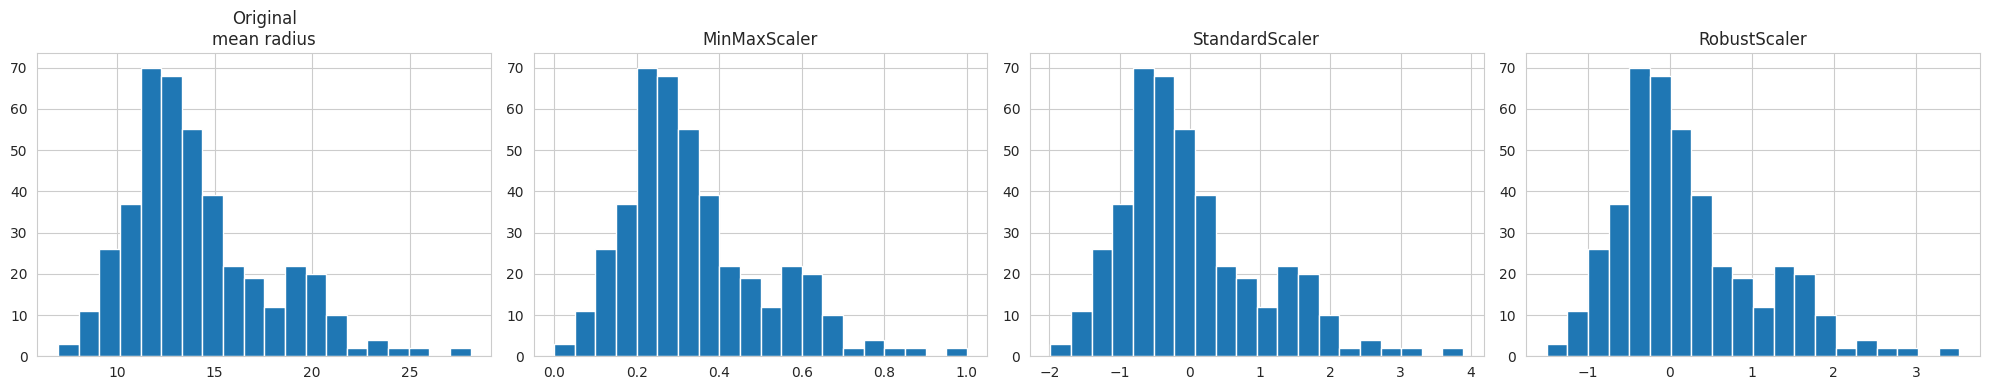

In [10]:
feature_idx = 0
feature_name = cancer.feature_names[feature_idx]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(X_train[:, feature_idx], bins=20)
axes[0].set_title(f"Original\n{feature_name}")

axes[1].hist(X_train_scaled[:, feature_idx], bins=20)
axes[1].set_title("MinMaxScaler")

axes[2].hist(X_train_standard[:, feature_idx], bins=20)
axes[2].set_title("StandardScaler")

axes[3].hist(X_train_robust[:, feature_idx], bins=20)
axes[3].set_title("RobustScaler")

plt.tight_layout()
plt.show()

### Interpretasi
Dari visualisasi di atas:
- **MinMaxScaler** memaksa data ke rentang 0–1
- **StandardScaler** memusatkan data di sekitar 0
- **RobustScaler** menyesuaikan data dengan median/IQR dan lebih tahan outlier

Pemilihan scaler tergantung karakteristik data dan algoritma yang digunakan.

# SECTION B — PRINCIPAL COMPONENT ANALYSIS (PCA)

## 8. Apa itu PCA?

**Principal Component Analysis (PCA)** adalah teknik **dimensionality reduction**.  
Tujuannya adalah mengurangi jumlah fitur sambil mempertahankan sebanyak mungkin informasi dari data.

PCA bekerja dengan mencari arah baru pada data yang disebut **principal components**:
- komponen pertama menangkap variasi terbesar,
- komponen kedua menangkap variasi terbesar berikutnya,
- dan seterusnya.

### Manfaat PCA
1. Mengurangi dimensi data
2. Mempercepat model
3. Mengurangi noise
4. Mempermudah visualisasi
5. Mengatasi korelasi tinggi antar fitur

## 9. PCA pada dataset Breast Cancer

Pada dataset ini terdapat banyak fitur numerik.
Kita akan menggunakan PCA untuk mereduksi fitur menjadi dua komponen utama agar bisa divisualisasikan.

In [11]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape data asli:", X.shape)
print("Shape data setelah scaling:", X_scaled.shape)

Shape data asli: (569, 30)
Shape data setelah scaling: (569, 30)


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape sebelum PCA:", X_scaled.shape)
print("Shape sesudah PCA :", X_pca.shape)

Shape sebelum PCA: (569, 30)
Shape sesudah PCA : (569, 2)


In [13]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance by 2 components:")
print(np.sum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.44272026 0.18971182]

Total explained variance by 2 components:
0.6324320765155944


### Interpretasi explained variance ratio
Nilai `explained_variance_ratio_` menunjukkan seberapa besar variasi data yang dijelaskan oleh setiap principal component.

Misalnya jika:
- PC1 = 0.44
- PC2 = 0.19

maka dua komponen pertama menjelaskan sekitar 63% variasi data.
Semakin besar total explained variance, semakin banyak informasi yang dipertahankan setelah reduksi dimensi.

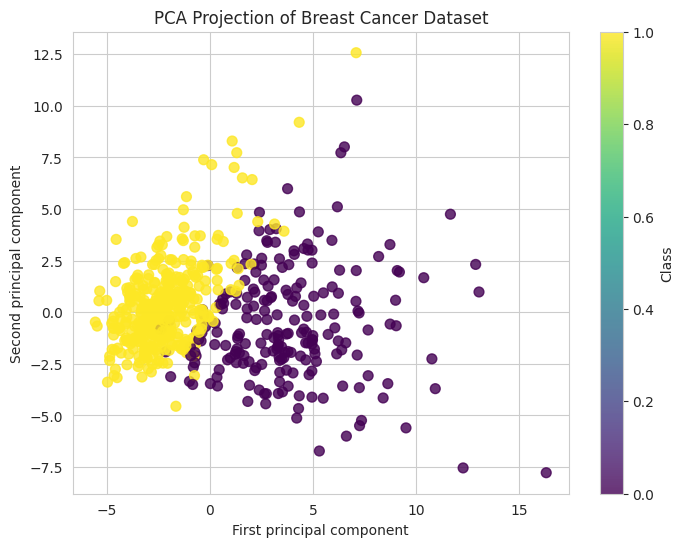

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.title("PCA Projection of Breast Cancer Dataset")
plt.colorbar(label="Class")
plt.show()

### Interpretasi plot PCA
Setiap titik merepresentasikan satu sampel.
Dua sumbu pada grafik bukan lagi fitur asli, melainkan kombinasi linear dari seluruh fitur.

Jika dua kelas tampak terpisah cukup jelas pada ruang PCA, berarti struktur kelas dapat ditangkap cukup baik oleh komponen utama.

## 10. Koefisien PCA / Principal Components

Kita juga bisa melihat bagaimana setiap fitur asli berkontribusi ke principal component.
Nilai komponen menunjukkan arah dan besar kontribusi fitur terhadap komponen tersebut.

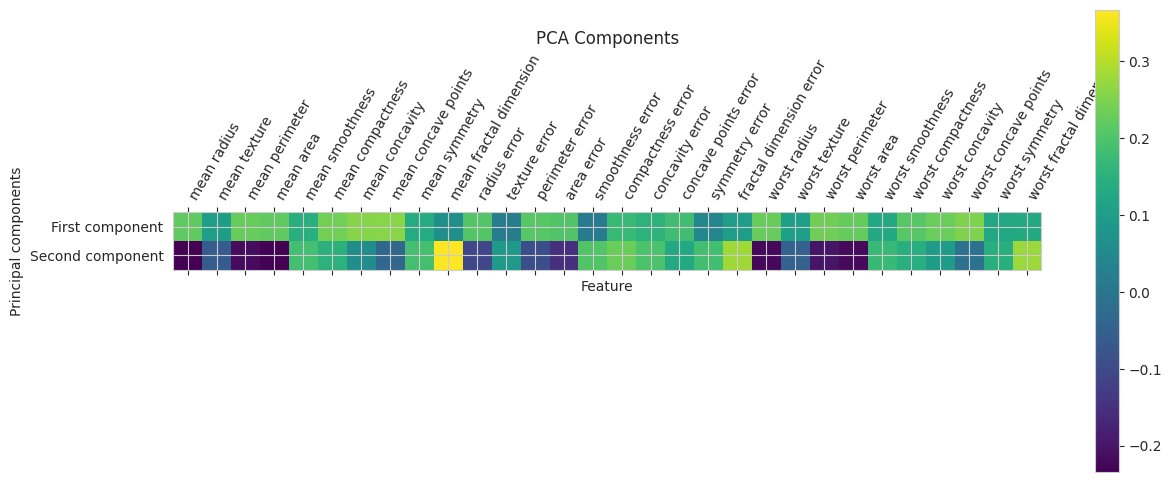

In [15]:
plt.figure(figsize=(14, 6))
plt.matshow(pca.components_, cmap='viridis', fignum=False)
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)), cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")
plt.title("PCA Components")
plt.show()

### Interpretasi PCA components
Pada heatmap di atas:
- kolom = fitur asli
- baris = principal component
- warna = besar kontribusi fitur terhadap komponen

Fitur dengan nilai absolut besar berpengaruh kuat terhadap principal component.
Dengan demikian, PCA juga membantu kita memahami struktur hubungan antar fitur.

## 11. Menentukan jumlah komponen PCA

Kita tidak harus selalu memilih 2 komponen.
Kadang kita ingin mengetahui berapa banyak komponen yang diperlukan untuk menjelaskan sebagian besar variasi data.

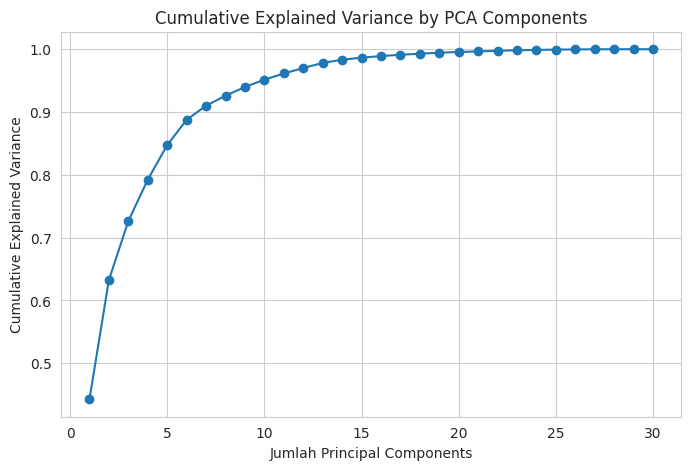

In [16]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Jumlah Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.grid(True)
plt.show()

### Interpretasi cumulative explained variance
Grafik ini membantu menentukan jumlah komponen yang ingin dipertahankan.

Contohnya:
- jika 95% variasi sudah tercapai pada 10 komponen,
- maka kita bisa mengurangi 30 fitur menjadi hanya 10 fitur sambil tetap mempertahankan sebagian besar informasi.

# SECTION C — MANIFOLD LEARNING WITH t-SNE

## 12. Apa itu t-SNE?

**t-SNE (t-distributed Stochastic Neighbor Embedding)** adalah teknik visualisasi untuk data berdimensi tinggi.

Berbeda dengan PCA:
- **PCA** adalah transformasi linear
- **t-SNE** adalah metode non-linear yang fokus menjaga kedekatan lokal antar data

Tujuan t-SNE:
- memetakan data berdimensi tinggi ke 2D/3D
- membantu melihat struktur cluster atau pola visual

### Catatan penting
t-SNE sangat bagus untuk visualisasi, tetapi:
- tidak cocok sebagai fitur input model utama
- hasilnya bisa berubah tergantung random state / parameter

## 13. t-SNE pada dataset Iris

Dataset Iris sering dipakai untuk visualisasi karena hanya memiliki 3 kelas dan fitur numerik yang sederhana.
Kita akan membandingkan bagaimana data terlihat dalam ruang 2D.

In [17]:
iris = load_iris()
X = iris.data
y = iris.target

print("Shape dataset iris:", X.shape)
print("Nama kelas:", iris.target_names)

Shape dataset iris: (150, 4)
Nama kelas: ['setosa' 'versicolor' 'virginica']


In [18]:
tsne = TSNE(random_state=42)
X_tsne = tsne.fit_transform(X)

print("Shape hasil t-SNE:", X_tsne.shape)

Shape hasil t-SNE: (150, 2)


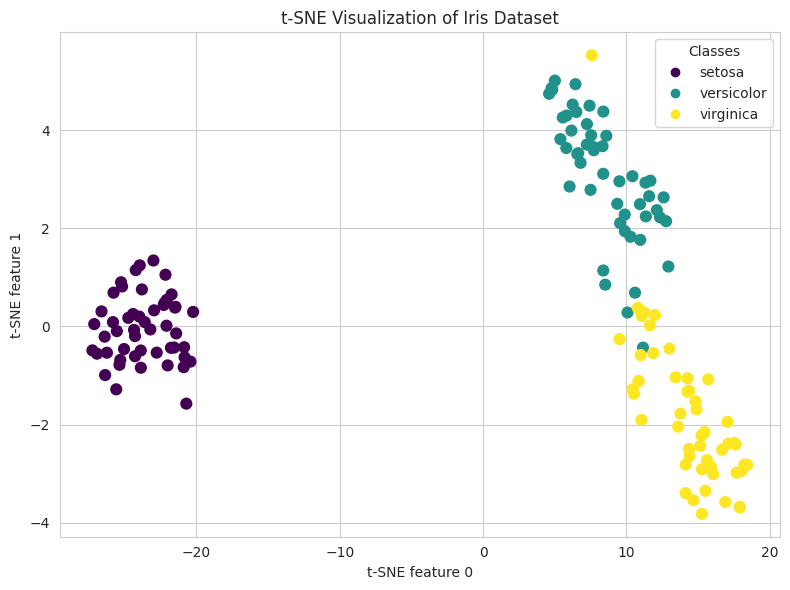

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='viridis',
    s=60
)

ax.set_xlabel("t-SNE feature 0")
ax.set_ylabel("t-SNE feature 1")
ax.set_title("t-SNE Visualization of Iris Dataset")

handles, _ = scatter.legend_elements()
ax.legend(handles, list(iris.target_names), title="Classes")

plt.tight_layout()
plt.show()

### Interpretasi hasil t-SNE
Jika t-SNE berhasil memetakan struktur data dengan baik, maka sampel dari kelas yang sama akan cenderung berkumpul dalam area yang berdekatan.

Pada dataset Iris, biasanya:
- **setosa** terpisah sangat jelas,
- **versicolor** dan **virginica** cenderung lebih dekat satu sama lain.

Ini membantu kita memahami struktur data sebelum melakukan pemodelan.

# SECTION D — CLUSTERING

## 14. Konsep Clustering

**Clustering** adalah proses mengelompokkan data yang mirip ke dalam kelompok yang sama (**cluster**).

Tujuan clustering:
- menemukan struktur tersembunyi pada data
- segmentasi pelanggan
- pengelompokan dokumen
- analisis pola perilaku
- eksplorasi data tanpa label

Pada chapter ini, kita akan mempelajari 3 algoritma clustering:
1. **k-Means**
2. **Agglomerative Clustering**
3. **DBSCAN**

## 15. Dataset sintetis untuk clustering

Agar bentuk cluster mudah dilihat, kita gunakan dataset sintetis dari `make_blobs`.

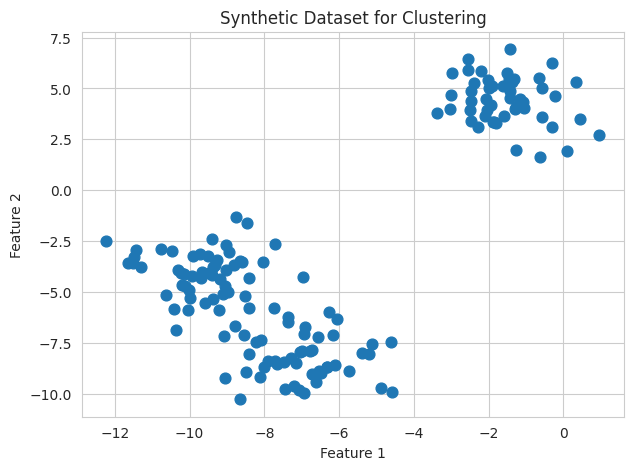

In [20]:
X, y = make_blobs(random_state=1, n_samples=150, centers=3, cluster_std=1.2)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=60)
plt.title("Synthetic Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 16. k-Means Clustering

**k-Means** membagi data ke dalam **k cluster** dengan cara:
1. memilih pusat cluster (centroid),
2. menempatkan setiap data ke centroid terdekat,
3. memperbarui centroid berdasarkan rata-rata anggota cluster,
4. mengulangi sampai stabil.

### Kelebihan
- sederhana
- cepat
- mudah dipahami

### Kekurangan
- harus menentukan jumlah cluster `k`
- sensitif terhadap inisialisasi
- kurang baik untuk bentuk cluster non-bulat

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

print("Cluster memberships:")
print(kmeans.labels_[:20])

print("\nCluster centers:")
print(kmeans.cluster_centers_)

Cluster memberships:
[1 1 1 2 2 2 2 1 1 1 1 1 2 1 0 2 2 2 2 0]

Cluster centers:
[[-1.54403469  4.43071846]
 [-7.0185855  -8.16720303]
 [-9.6322617  -4.0263156 ]]


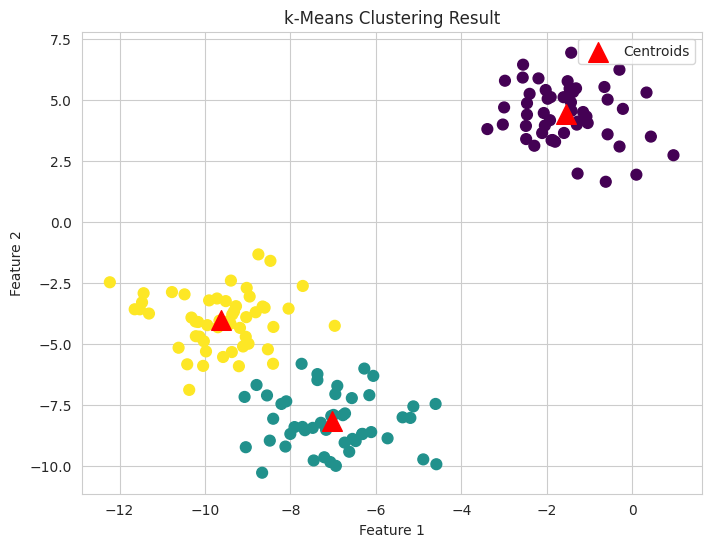

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=60)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='^',
    c='red',
    s=200,
    label='Centroids'
)
plt.title("k-Means Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Interpretasi k-Means
- Titik dengan warna yang sama berada pada cluster yang sama.
- Segitiga merah menunjukkan centroid.
- k-Means bekerja baik jika cluster berbentuk cukup bulat dan terpisah jelas.

## 17. Pengaruh jumlah cluster pada k-Means

Sekarang kita lihat bagaimana hasil clustering berubah ketika nilai `k` diubah.

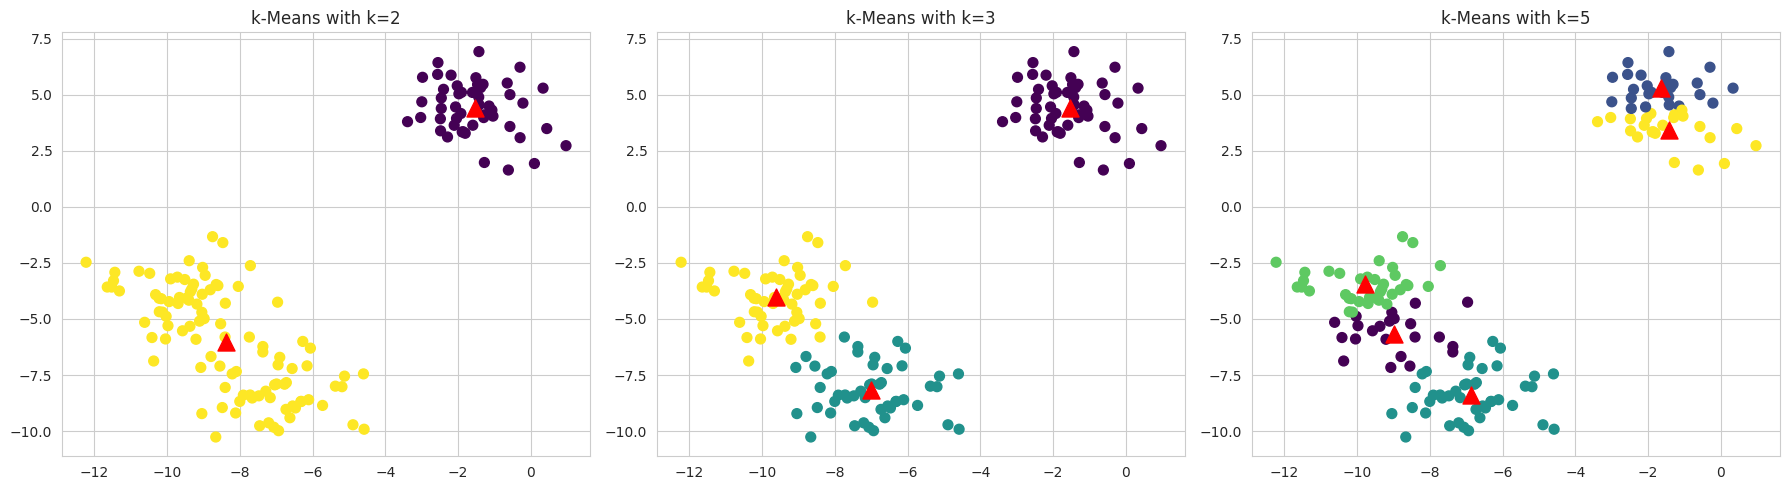

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n_clusters in zip(axes, [2, 3, 5]):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        marker='^',
        c='red',
        s=150
    )
    ax.set_title(f"k-Means with k={n_clusters}")

plt.tight_layout()
plt.show()

### Interpretasi
- Jika `k` terlalu kecil, beberapa cluster berbeda bisa tergabung.
- Jika `k` terlalu besar, satu cluster alami bisa terpecah menjadi beberapa bagian.
- Menentukan `k` yang tepat adalah salah satu tantangan utama dalam clustering.

## 18. Agglomerative Clustering

**Agglomerative Clustering** adalah metode **hierarchical clustering**.

Cara kerjanya:
1. awalnya setiap titik dianggap sebagai cluster terpisah,
2. lalu dua cluster terdekat digabung,
3. proses diulang sampai jumlah cluster yang diinginkan tercapai.

Kelebihan:
- tidak bergantung pada centroid
- dapat membentuk struktur hierarki cluster

Kekurangan:
- lebih lambat daripada k-Means pada data besar
- hasil bisa sensitif terhadap definisi jarak / linkage

In [24]:
agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)

print("Cluster labels:")
print(assignment[:20])

Cluster labels:
[0 0 0 2 2 2 2 0 0 0 0 0 2 0 1 2 2 2 2 1]


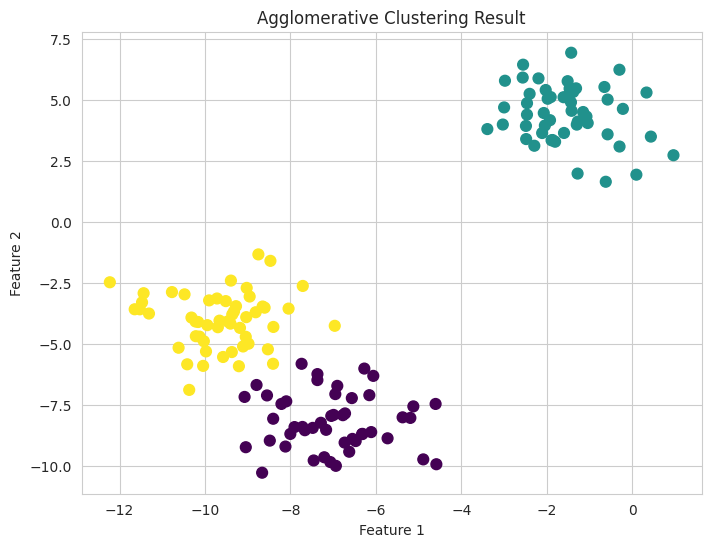

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=assignment, cmap='viridis', s=60)
plt.title("Agglomerative Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Interpretasi
Agglomerative clustering juga mengelompokkan data ke beberapa cluster, tetapi pendekatannya berbeda dari k-Means karena menggunakan proses penggabungan bertahap.

Pada data sederhana seperti blobs, hasilnya sering mirip dengan k-Means.
Namun pada data lain, hasilnya bisa berbeda cukup signifikan.

## 19. Dendrogram

Salah satu keunggulan hierarchical clustering adalah kita dapat melihat **dendrogram**, yaitu visualisasi proses penggabungan cluster.

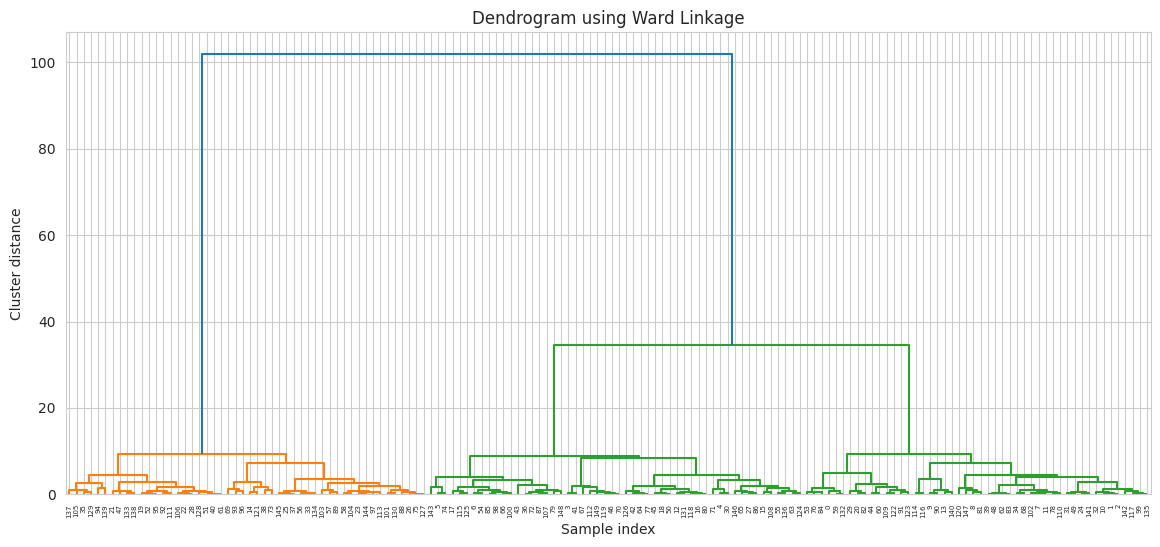

In [26]:
linkage_array = ward(X)

plt.figure(figsize=(14, 6))
dendrogram(linkage_array)
plt.title("Dendrogram using Ward Linkage")
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

### Interpretasi dendrogram
Pada dendrogram:
- bagian bawah = titik data individual
- cabang yang bergabung = cluster yang digabung
- tinggi penggabungan = jarak antar cluster

Semakin tinggi dua cabang bergabung, semakin berbeda cluster tersebut.
Dendrogram membantu memperkirakan jumlah cluster yang wajar.

## 20. DBSCAN

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** mengelompokkan data berdasarkan **kepadatan**.

Keunggulan DBSCAN:
- tidak perlu menentukan jumlah cluster di awal
- dapat mendeteksi noise/outlier
- mampu menemukan cluster dengan bentuk non-bulat

Parameter penting:
1. **eps** = radius tetangga
2. **min_samples** = minimum jumlah titik dalam radius agar dianggap area padat

In [27]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters = dbscan.fit_predict(X)

print("DBSCAN cluster labels:")
print(clusters[:30])

print("\nUnique labels:")
print(np.unique(clusters))

DBSCAN cluster labels:
[ 0  0  0  0  0 -1  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  1  1  1
  0  1  1  0  1  0]

Unique labels:
[-1  0  1]


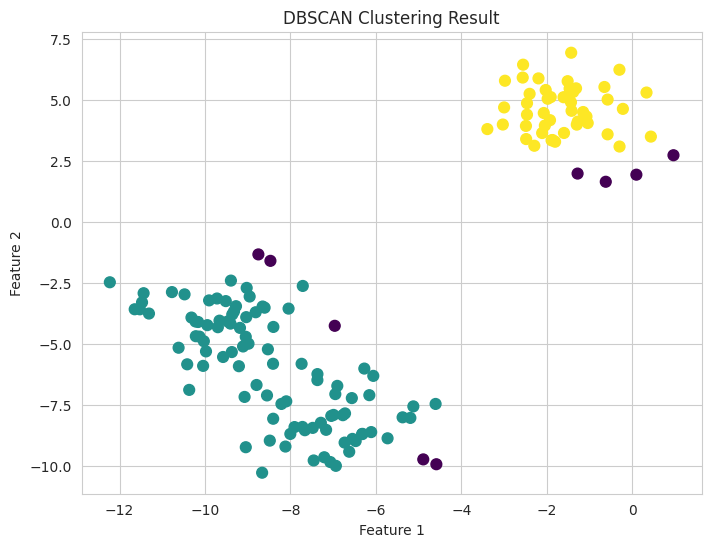

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=60)
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Interpretasi DBSCAN
- Titik dengan label **-1** dianggap **noise** / outlier
- DBSCAN bekerja baik jika cluster dibedakan oleh kepadatan lokal
- DBSCAN sering lebih fleksibel daripada k-Means untuk bentuk cluster yang kompleks

## 21. Perbandingan k-Means, Agglomerative Clustering, dan DBSCAN

Sekarang kita tampilkan ketiga hasil clustering secara berdampingan.

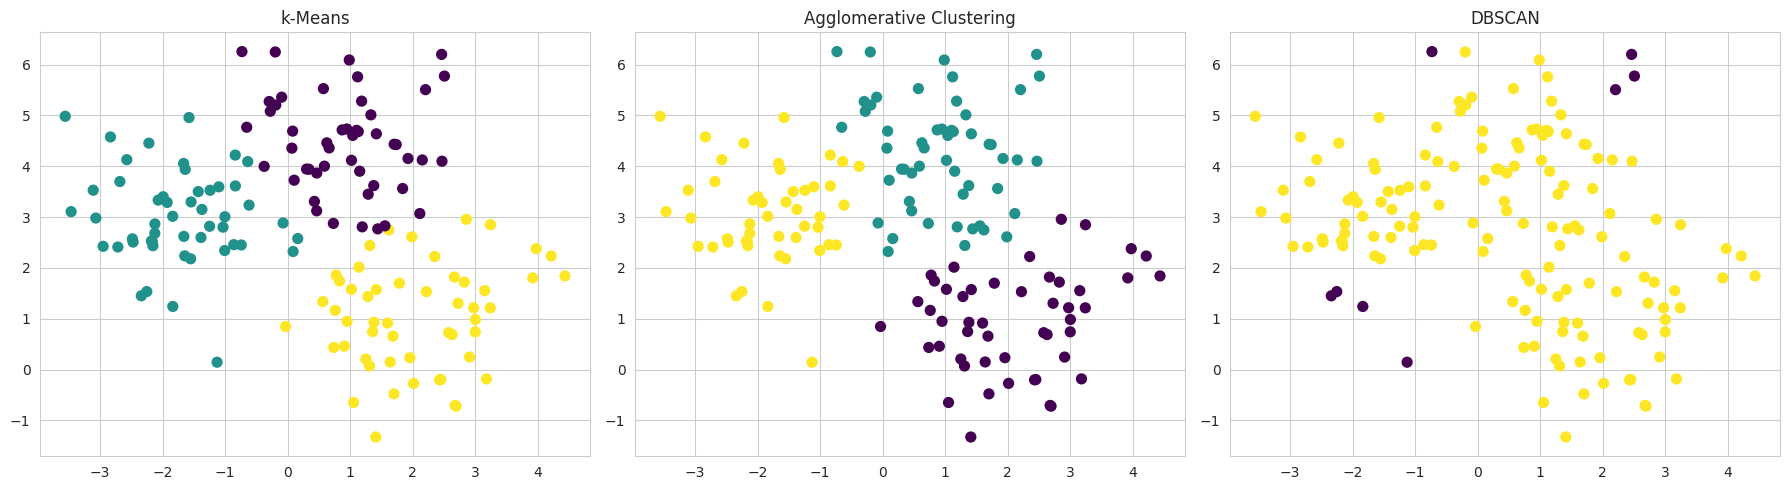

In [29]:
X, y = make_blobs(random_state=0, n_samples=150, centers=3, cluster_std=1.0)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)

dbscan = DBSCAN(eps=0.9, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50)
axes[0].set_title("k-Means")

axes[1].scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='viridis', s=50)
axes[1].set_title("Agglomerative Clustering")

axes[2].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=50)
axes[2].set_title("DBSCAN")

plt.tight_layout()
plt.show()

### Perbandingan singkat algoritma clustering

## 1. k-Means
- perlu menentukan jumlah cluster `k`
- cocok untuk cluster bulat / terpisah jelas
- cepat dan efisien

## 2. Agglomerative Clustering
- membangun hierarki cluster
- dapat divisualisasikan dengan dendrogram
- cocok untuk eksplorasi struktur cluster

## 3. DBSCAN
- tidak perlu menentukan jumlah cluster
- bisa mendeteksi outlier
- cocok untuk cluster bentuk arbitrer
- sensitif terhadap parameter `eps` dan `min_samples`

# SECTION E — CLUSTERING ON BREAST CANCER DATA

## 22. Clustering pada dataset nyata

Sekarang kita coba terapkan clustering pada dataset Breast Cancer.
Karena clustering adalah unsupervised learning, model tidak akan menggunakan label `malignant/benign` saat membentuk cluster.

Namun setelah cluster terbentuk, kita bisa membandingkan cluster dengan label asli untuk melihat apakah ada pola yang sesuai.

In [30]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape data:", X_scaled.shape)
print("Jumlah kelas asli:", np.unique(y))

Shape data: (569, 30)
Jumlah kelas asli: [0 1]


In [31]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(pd.Series(clusters).value_counts())

Cluster counts:
0    375
1    194
Name: count, dtype: int64


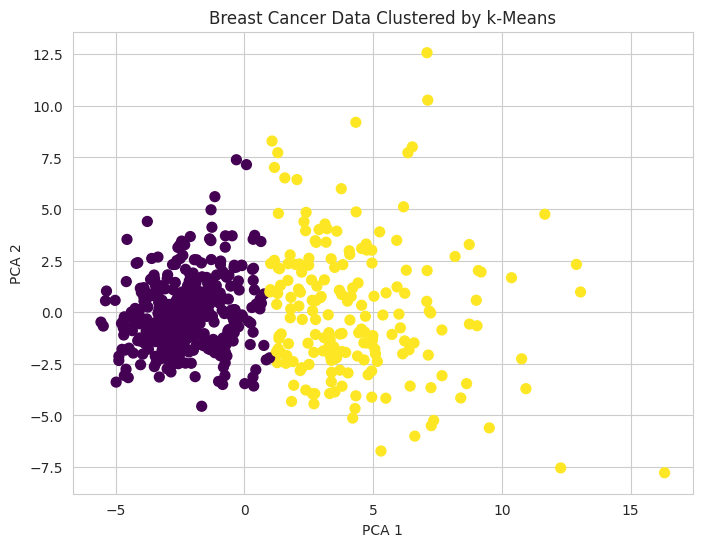

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title("Breast Cancer Data Clustered by k-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [33]:
comparison = pd.crosstab(
    pd.Series(y, name="True Label"),
    pd.Series(clusters, name="Cluster")
)

comparison

Cluster,0,1
True Label,,
0,36,176
1,339,18


### Interpretasi tabel perbandingan
Tabel di atas menunjukkan hubungan antara:
- **label asli** dataset (`True Label`)
- **cluster** hasil unsupervised learning

Karena clustering tidak menggunakan label asli, hasil cluster belum tentu identik dengan kelas sebenarnya.
Namun jika satu cluster didominasi oleh satu kelas tertentu, berarti struktur data cukup konsisten dengan label aslinya.

# SECTION F — SUMMARY OF CHAPTER 3

## 23. Ringkasan Chapter 3

Chapter 3 membahas dua hal besar: **preprocessing** dan **unsupervised learning**.

### A. Preprocessing
Preprocessing sangat penting agar fitur berada pada skala yang sesuai.
Tiga scaler utama:
- **MinMaxScaler** → skala 0–1
- **StandardScaler** → mean 0, std 1
- **RobustScaler** → tahan outlier

### B. PCA
PCA adalah teknik reduksi dimensi yang mengubah data ke sekumpulan principal components.
PCA berguna untuk:
- mengurangi jumlah fitur,
- mempercepat komputasi,
- mengurangi noise,
- memvisualisasikan data.

### C. t-SNE
t-SNE adalah teknik visualisasi non-linear untuk data berdimensi tinggi.
Metode ini sangat berguna untuk eksplorasi pola dan struktur data.

### D. Clustering
Tiga algoritma clustering utama:
1. **k-Means**
2. **Agglomerative Clustering**
3. **DBSCAN**

Masing-masing memiliki karakteristik berbeda:
- **k-Means** cepat dan sederhana
- **Agglomerative** menghasilkan struktur hierarki
- **DBSCAN** bisa mendeteksi noise dan bentuk cluster kompleks

### Inti pembelajaran Chapter 3
- data perlu diproses dengan baik sebelum digunakan
- unsupervised learning membantu menemukan struktur tersembunyi tanpa label
- PCA dan t-SNE sangat berguna untuk eksplorasi dan visualisasi
- clustering membantu memahami pola kelompok dalam data

## 24. Kesimpulan Pribadi

Dari Chapter 3, saya memahami bahwa:
1. preprocessing adalah fondasi penting sebelum membangun model,
2. scaling dapat sangat memengaruhi performa algoritma,
3. PCA membantu menyederhanakan data tanpa kehilangan terlalu banyak informasi,
4. t-SNE membantu melihat struktur data yang sulit divisualisasikan secara langsung,
5. clustering adalah alat penting untuk analisis data tanpa label.

Chapter ini menunjukkan bahwa Machine Learning bukan hanya soal prediksi, tetapi juga soal **memahami struktur data**.

# End of Chapter 3 Notebook

In [34]:
print("Chapter 3 selesai direproduksi dan diringkas.")

Chapter 3 selesai direproduksi dan diringkas.
